In [5]:
import hashlib
import random
import requests
import json
from typing import Dict, Any, List

# ==============================================================================
# Step 1: External Configuration and Marine Life Data
# ==============================================================================
# API Key for Google Custom Search (Needs replacement with a real key)
import os
GOOGLE_API_KEY = os.getenv("GOOGLE_CUSTOM_SEARCH_API_KEY", "")
# Custom Search Engine ID (CX) configured for Wikipedia
GOOGLE_CSE_ID = "b1f49115b44814094"
# Base URL for the Google Custom Search API (Image search)
SEARCH_API_URL = "https://www.googleapis.com/customsearch/v1"

# List of Marine Life Identities in Phillip Island
PHILIP_ISLAND_MARINE_LIFE = [
    {
        "species_en": "King George Whiting",
        "species_cn": "乔治王白鲑",
        "age_size": "Covered in silver armor, with a slender body, the 'Nobleman' of the ocean.",
        "habitat": "Sandy seabed, where they enjoy strolling on fine sand searching for delicious shellfish.",
        "personality": "Elegant, cautious, sensitive sense of smell, a 'Gourmet', requires high water quality.",
        "special_feature": "【Invisible Treasure Hunter】Its long nose acts like a probe to quickly search the sand for the most hidden snacks.",
        "fun_story_cn": "The King George Whiting is the 'Guardian of Time' in the ocean; their arrival and departure signals fishermen when to cast or retrieve their nets.",
        "image_url": "images/cartoon_king_george_whiting.png"
    },
    {
        "species_en": "Weedy Seadragon",
        "species_cn": "多刺海龙",
        "age_size": "Covered in a 'camouflage veil' resembling seaweed, an artwork of the deep sea.",
        "habitat": "Hidden seagrass beds, where they quietly drift, pretending to be water plants.",
        "personality": "Quiet, extremely patient, skilled in observation, the ocean's 'Master of Disguise'.",
        "special_feature": "【Seagrass Phantom】Their bodies gently sway with the waves, possessing the ocean's strongest stealth ability.",
        "fun_story_cn": "Seadragons are the ocean's 'Super Dads'; the males carry the eggs on their tails, like swimming with a cluster of little stars.",
        "image_url": "images/cartoon_seadragon.png"
    },
    {
        "species_en": "Port Jackson Shark",
        "species_cn": "杰克逊港鲨",
        "age_size": "Has an armor-like head, looks imposing but has a gentle temperament.",
        "habitat": "Shallow, rocky, and seaweed-covered areas, prefers to come out at night.",
        "personality": "Curious, slow-moving, loves to explore, the ocean's 'Peacekeeper'.",
        "special_feature": "【Ocean Bulldozer】It has specialized teeth for crushing shells, the 'Environmental Worker' of the seabed.",
        "fun_story_cn": "The Port Jackson shark's eggs are spiral-shaped, resembling an 'Underwater Chocolate Cone', to protect its babies.",
        "image_url": "images/cartoon_port_jackson_shark.png"
    },
    {
        "species_en": "Big-bellied Seahorse",
        "species_cn": "大腹海马",
        "age_size": "Has a round belly, like a small pouch filled with ocean tales.",
        "habitat": "Near seagrass and sponges, uses its tail to grasp seagrass while waiting for food.",
        "personality": "Slow-moving, contemplative, very romantic, loves to perform a 'Slow Dance' in the sea.",
        "special_feature": "【Underwater Postman】They are the only creatures where the 'Dad' incubates the babies, carrying the ocean's hope in their belly.",
        "fun_story_cn": "The Big-bellied Seahorse swims in a unique way, like an elegant 'Underwater Ballerina', propelling itself with a small fan on its back.",
        "image_url": "images/cartoon_big_belly_seahorse.png"
    },
    {
        "species_en": "Zebra Fish",
        "species_cn": "斑马鱼",
        "age_size": "Body is black and white striped, like wearing an 'Ocean Stripes Shirt'.",
        "habitat": "Near rocky reefs and breakwaters, enjoys playing in strong currents.",
        "personality": "Lively, active, the ocean's 'Athlete', likes to move in large schools.",
        "special_feature": "【Stripe Navigator】The stripes on its body help them instantly recognize their family members in a chaotic school.",
        "fun_story_cn": "The Zebra Fish's stripes tell other fish: 'Maintain formation, proceed in order!' They are the ocean's 'Traffic Controllers'.",
        "image_url": "images/cartoon_zebra_fish.png"
    },
    {
        "species_en": "Southern Blue Devil",
        "species_cn": "南方蓝魔鬼",
        "age_size": "Covered in charming deep blue spots, like stars in the night sky.",
        "habitat": "Deep water rock caves or inside shipwrecks, lives in a hidden 'Underwater Castle'.",
        "personality": "Solitary, mysterious, territorial but kind-hearted, the 'Guardian God' of the deep-sea caves.",
        "special_feature": "【Starry Sky Protector】They possess the ocean's most beautiful blue; it's said that a glance brings good luck.",
        "fun_story_cn": "The Blue Devil is the ocean's rarest 'Sculptor'; they use rocks and coral to decorate their homes.",
        "image_url": "images/cartoon_blue_devil.png"
    },
    {
        "species_en": "Old Wife",
        "species_cn": "老太婆鱼",
        "age_size": "Flat body with a high dorsal fin, like wearing an 'Ancient Hat'.",
        "habitat": "Rocky reefs and pier pilings, likes to hide in the shadow and observe the world.",
        "personality": "Cautious, sensitive, emits a 'cawing' warning sound when in danger, the ocean's 'Early Warning Aircraft'.",
        "special_feature": "【Deep Sea Harper】It can rub its gill covers to produce a loud 'humming' sound, alerting all neighbors to safety.",
        "fun_story_cn": "The Old Wife is the wisest fish in the ocean; the stripes on its body record all the secrets of the bay.",
        "image_url": "images/cartoon_old_wife.png"
    },
    {
        "species_en": "Snapper",
        "species_cn": "鲷鱼",
        "age_size": "Strong build with a noticeable 'Lump of Wisdom' on its head.",
        "habitat": "Sandy-muddy areas at the junction of deep and shallow water, prefers to move in schools.",
        "personality": "Brave, adaptable, the ocean's 'Survival Expert'; the older it gets, the bigger the lump on its head.",
        "special_feature": "【Lump of Wisdom】As it ages, the bump on its head represents the wealth of experience it has accumulated in the ocean.",
        "fun_story_cn": "Snappers are pink 'Little Princesses/Princes' when young, but their color darkens as they go on ocean adventures.",
        "image_url": "images/cartoon_snapper.png"
    },
    {
        "species_en": "Elephant Fish",
        "species_cn": "象鱼（象鲨）",
        "age_size": "Has a long, slender snout like an elephant's trunk, silver body, the 'Dumbo' of the ocean.",
        "habitat": "Sandy-muddy bottoms of bays, uses its long nose to dig for food.",
        "personality": "Gentle, shy, the ocean's 'Treasure Hunter'; its daily task is to retrieve lost ocean coins.",
        "special_feature": "【Underwater Probe】Its long snout acts like a metal detector, sensing tiny electrical signals beneath the sand.",
        "fun_story_cn": "The Elephant Fish is called the 'Nose Ancestor' in the ocean school because it has the most unique nose among marine creatures.",
        "image_url": "images/cartoon_elephant_fish.png"
    },
    {
        "species_en": "Southern Fiddler Ray (Banjo)",
        "species_cn": "南方小提琴鳐",
        "age_size": "Body shaped like a unique small violin (Banjo), with a slender tail.",
        "habitat": "Calm, sandy shallow areas, likes to stay quiet and listen to the waves.",
        "personality": "Quiet, musically talented, the ocean's 'Solitary Musician'.",
        "special_feature": "【Peaceful Harpsichordist】The shape of their body absorbs vibrations in the water, allowing them to sense distant storms.",
        "fun_story_cn": "The Fiddler Ray's daily task is to use its body to draw 'musical staffs' on the sand, recording the ocean's tidal symphony.",
        "image_url": "images/cartoon_fiddler_ray.png"
    },
    {
        "species_en": "Gummy Shark",
        "species_cn": "星斑鲨",
        "age_size": "Smooth skin covered in small white spots, like stars in the night sky.",
        "habitat": "Sandy plains, where they search for delicious snacks in the sand.",
        "personality": "Gentle, cautious, likes to patrol quietly on the seabed, the ocean's 'Night Shift Security'.",
        "special_feature": "【Night Sky Messenger】The white spots on its body are fragments of starlight captured in the deep sea, used to illuminate its path.",
        "fun_story_cn": "The Gummy Shark is the friendliest shark in the ocean; they play hide-and-seek with seals but never eat small fish.",
        "image_url": "images/cartoon_gummy_shark.png"
    },
    {
        "species_en": "Shorthead Seahorse",
        "species_cn": "短头海马",
        "age_size": "Smaller than the Big-bellied Seahorse, with a shorter head and snout, looking cuter.",
        "habitat": "Dense seagrass, where they cling tightly to the grass to avoid being swept away by currents.",
        "personality": "Clingy, highly dependent, likes to live in groups, the 'Little Darling' of the seahorse family.",
        "special_feature": "【Grasping Master】Their tail can firmly grasp anything like a hook, a magic weapon against getting lost.",
        "fun_story_cn": "Shorthead Seahorses gather every morning to perform 'Seagrass Calisthenics' together, resisting the current's impact.",
        "image_url": "images/cartoon_shorthead_seahorse.png"
    },
    {
        "species_en": "Australian Anchovy",
        "species_cn": "澳洲鳀鱼",
        "age_size": "Small and silver, like a squad of shining fish soldiers.",
        "habitat": "Open waters, always swimming in large schools.",
        "personality": "Collectivist, timid, only feels safe in a huge group.",
        "special_feature": "【Silver Lightning】They can instantly change direction, like a silver mist, dazzling predators.",
        "fun_story_cn": "Anchovy schools are the ocean's 'Mobile Library'; every fish records different pieces of ocean knowledge.",
        "image_url": "images/cartoon_anchovy.png"
    },
    {
        "species_en": "Australian Salmon (Eastern)",
        "species_cn": "澳洲鲑鱼",
        "age_size": "Sturdy and powerful, the ocean's 'Long-Distance Runner'.",
        "habitat": "Open waters and estuaries; they travel between the ocean and rivers throughout their lives.",
        "personality": "Energetic, goal-oriented, the ocean's 'Traveler', always heading towards the next destination.",
        "special_feature": "【Migration Compass】Their bodies contain a natural magnetic compass guiding them back to the river of their birth.",
        "fun_story_cn": "The Australian Salmon's journey is to find the 'Legendary Gem River'; the further they swim, the shinier their scales become.",
        "image_url": "images/cartoon_australian_salmon.png"
    },
    {
        "species_en": "Bluefin Gurnard",
        "species_cn": "蓝鳍鲂",
        "age_size": "Large and hard head, most striking are their blue pectoral fins, like fans.",
        "habitat": "Sandy-muddy seabed, where they like to 'walk' on the sand using their pectoral fins.",
        "personality": "Curious, slow to warm up, loves to explore, the 'Wanderer' of the seabed, always leaving unique footprints.",
        "special_feature": "【Underwater Wings】Their blue pectoral fins can be spread out like butterfly wings to scare off enemies.",
        "fun_story_cn": "Bluefin Gurnards use their specialized pelvic fins to 'draw maps' in the sand, marking where the tastiest shells are found.",
        "image_url": "images/cartoon_bluefin_gurnard.png"
    },
    {
        "species_en": "John Dory",
        "species_cn": "多利鱼",
        "age_size": "Flat body with a massive eye and mouth, and a unique black spot on each side.",
        "habitat": "Open deep water, they are 'Ghost Hunters' camouflaged in the water.",
        "personality": "Cunning, patient, the ocean's 'Camouflage Hunter', waiting for prey to approach.",
        "special_feature": "【Fingerprint of God】The black spots on their sides are said to be the fingerprints left by St. Peter, possessing sacred power.",
        "fun_story_cn": "Although the John Dory's body is flat, it can reflect light like a mirror, making it completely disappear in the water.",
        "image_url": "images/cartoon_john_dory.png"
    },
    {
        "species_en": "Luderick (Blackfish)",
        "species_cn": "黑毛鱼（瓜子鱲）",
        "age_size": "Has vertical black stripes, like wearing an 'Ocean Uniform'.",
        "habitat": "Rocky coasts and estuaries; they are vegetarians, eating only seaweed.",
        "personality": "Diligent, picky eater, the ocean's 'Green Cleaner', responsible for tidying up the underwater garden.",
        "special_feature": "【Green Diner】They are one of the few fish that only eat seagrass, responsible for keeping the underwater environment clean.",
        "fun_story_cn": "The Luderick's stripes record all the types of seagrass it has eaten; the clearer the stripes, the more qualified it is as an 'Ocean Gardener'.",
        "image_url": "images/cartoon_luderick.png"
    },
    {
        "species_en": "Silver Trevally",
        "species_cn": "银色鲹",
        "age_size": "Fully shiny silver, with a smooth body, like a fast-moving silver coin.",
        "habitat": "Mid-to-upper water columns, likes to patrol near wharves and reefs.",
        "personality": "Friendly, playful, the ocean's 'Express Courier', constantly darting between different locations.",
        "special_feature": "【Ocean Silver Shield】Their silver body can scatter light in the water, making them look like a flash of light when moving quickly.",
        "fun_story_cn": "The Silver Trevally's tail is like a giant pair of scissors; they use it to cut seagrass, creating a quick shortcut for themselves.",
        "image_url": "images/cartoon_silver_trevally.png"
    },
    {
        "species_en": "Yellow-eye Mullet",
        "species_cn": "黄眼鲻鱼",
        "age_size": "Has distinctive large yellow eyes and a broad head, like wearing 'Yellow Goggles'.",
        "habitat": "Shallow, sandy-muddy areas in estuaries and bays, prefers to feed near the water surface.",
        "personality": "Gentle, very curious, the ocean's 'Surface Observer', deeply interested in the world above the shore.",
        "special_feature": "【Golden Detector】Their yellow eyes filter the reflection off the water surface, allowing them to clearly see both below and above the water.",
        "fun_story_cn": "Yellow-eye Mullet like to leap out of the water, not to escape, but to see if the clouds in the sky resemble delicious seaweed.",
        "image_url": "images/cartoon_yellow_eye_mullet.png"
    },
    {
        "species_en": "Ornate Cowfish",
        "species_cn": "华丽箱鲀",
        "age_size": "Body is square-shaped, like a small wooden box with beautiful patterns.",
        "habitat": "Around seagrass beds and coral reefs, moves slowly.",
        "personality": "Slow-paced, elegant, proud of its 'Gorgeous Outfit', the ocean's 'Fashion Pioneer'.",
        "special_feature": "【Armor Guard】Its body is covered in hard bone plates, like wearing an indestructible 'Square Armor'.",
        "fun_story_cn": "Cowfish are the ocean's 'Mobile Treasure Chests'. Legend says they are couriers delivering toys to little sea creatures.",
        "image_url": "images/cartoon_ornate_cowfish.png"
    },
    {
        "species_en": "Southern Porcupinefish",
        "species_cn": "南方刺鲀",
        "age_size": "Usually round, but turns into an 'Ocean Balloon' covered in sharp spines when threatened.",
        "habitat": "Near reefs and seagrass beds, doesn't swim fast.",
        "personality": "Kind, but a bit timid. When in trouble, it quickly inflates to show its strength.",
        "special_feature": "【Balloon Superman】It can inhale a large amount of water, instantly turning into a spiky ball, the ocean's 'Self-Defense Master'.",
        "fun_story_cn": "The Porcupinefish's spines are used to play 'hide-and-seek' with crabs, but if someone bullies it, it turns into a spiky 'sea urchin candy'.",
        "image_url": "images/cartoon_porcupinefish.png"
    },
    {
        "species_en": "Smooth Toadfish",
        "species_cn": "光滑蟾鱼",
        "age_size": "Small body, smooth skin, with a mouth that always seems to be smiling.",
        "habitat": "Sandy-muddy seabed, likes to bury itself in the mud, only showing its eyes and mouth.",
        "personality": "Optimistic, curious, the 'Happy Go Lucky' of the seabed, always observing the world with a smile.",
        "special_feature": "【Smiling Prophet】It can absorb oxygen from the water through its mouth to predict tidal changes.",
        "fun_story_cn": "The Toadfish is the ocean's 'Master of Disguise'; it loves turning itself into a 'Mud Cake' in the mud, tricking small fish into thinking it's a snack.",
        "image_url": "images/cartoon_smooth_toadfish.png"
    },
    {
        "species_en": "Rock Flathead",
        "species_cn": "岩石平头鱼",
        "age_size": "Flat and broad head, body shaped like a long arrow.",
        "habitat": "Rocky reefs and pier bottoms, likes to rest its head on a stone.",
        "personality": "Patient, expert hunter, possesses the wisdom of 'waiting for the rabbit', the ocean's 'Ambush Hero'.",
        "special_feature": "【Eyes of the Earth】Its eyes are on the top of its head, allowing it to see all small fish swimming above it.",
        "fun_story_cn": "The Flathead is the ocean's 'Stone Statue'; it remains motionless to share ancient secrets about Phillip Island with passing fish.",
        "image_url": "images/cartoon_rock_flathead.png"
    },
    {
        "species_en": "Banded Stingaree",
        "species_cn": "带纹魟鱼",
        "age_size": "Flat body like a round disc, with a slender tail, like an underwater flying carpet.",
        "habitat": "Sandy seabed and seagrass beds, buries itself in the sand.",
        "personality": "Calm, skilled in camouflage, likes to quietly observe the world above the surface, the seabed's 'Invisible Detective'.",
        "special_feature": "【Invisible Flying Carpet】They can instantly cover their entire body with sand, disappearing like magic.",
        "fun_story_cn": "The Banded Stingaree is the seabed's 'Sand Artist'; whenever they swim by, they leave beautiful wavy patterns on the sand.",
        "image_url": "images/cartoon_banded_stingaree.png"
    },
    {
        "species_en": "Dusky Morwong",
        "species_cn": "暗色三齿鲈",
        "age_size": "Strong body, dark in color, with noticeable lips on its head.",
        "habitat": "Rocky and seaweed-covered waters; they are schooling animals.",
        "personality": "Steady, brave, the ocean's 'Team Leader', always guiding the group to find the best seaweed.",
        "special_feature": "【Seaweed Harvester】Their lips are very thick, allowing them to accurately nibble seaweed off rocks.",
        "fun_story_cn": "The 'Team Leader' of the Dusky Morwong always swims at the front, ensuring everyone gets the cleanest seaweed.",
        "image_url": "images/cartoon_dusky_morwong.png"
    },
    {
        "species_en": "Longsnout Boarfish",
        "species_cn": "长吻野猪鱼",
        "age_size": "Has a long snout and a high dorsal fin like a flag.",
        "habitat": "Deep rock reefs; they move slowly and look like underwater statues.",
        "personality": "Arrogant, mysterious, the ocean's 'Flag Bearer'; its dorsal fin points the direction.",
        "special_feature": "【Deep Sea Banner】Its dorsal fin can sense faint vibrations in the current, providing early warning of danger.",
        "fun_story_cn": "The Longsnout Boarfish's daily task is to use its long snout to 'draw secret markings' in the sand that only marine creatures can understand.",
        "image_url": "images/cartoon_longsnout_boarfish.png"
    },
    {
        "species_en": "Magpie Perch",
        "species_cn": "喜鹊鲈鱼",
        "age_size": "Black and white body, conspicuous like a magpie on land.",
        "habitat": "Shallow rocky areas, they like to be active in sunny spots.",
        "personality": "Lively, curious, the ocean's 'Bringer of Good News', makes a sound when it sees something interesting.",
        "special_feature": "【Feathers of Fortune】Their black and white fins resemble magpie feathers, bringing good luck and joy.",
        "fun_story_cn": "Magpie Perch believe that finding a shiny stone in the sea grants a wish, so they are constantly searching for underwater treasures.",
        "image_url": "images/cartoon_magpie_perch.png"
    },
    {
        "species_en": "Tiger Flathead",
        "species_cn": "老虎平头鱼",
        "age_size": "Stripes like a tiger on its flat, broad body.",
        "habitat": "Sandy-muddy seabed; they are ambush predators.",
        "personality": "Brave, composed, the ocean's 'Hunting Master', always quietly waiting for the best moment.",
        "special_feature": "【Camouflage Battle Robe】The tiger stripes on its body allow it to perfectly blend into the sandy-muddy environment.",
        "fun_story_cn": "Tiger Flatheads perform 'camouflage training' every day to see who can turn into a piece of sand the fastest.",
        "image_url": "images/cartoon_tiger_flathead.png"
    },
    {
        "species_en": "Tasselled Anglerfish",
        "species_cn": "流苏躄鱼",
        "age_size": "Body covered in tassel-like fins, like wearing a worn-out 'Seaweed Coat'.",
        "habitat": "Around sponges and mosses; they move slowly like sponges.",
        "personality": "Eccentric, patient, the ocean's 'Fishing Expert'.",
        "special_feature": "【Lure Fishing Rod】It has a 'small fishing rod' on its head that can swing to attract curious small fish closer.",
        "fun_story_cn": "Tasselled Anglerfish are not fishing for fish; they are fishing for 'curiosity', waiting to see who will be the first to say hello.",
        "image_url": "images/cartoon_tasselled_anglerfish.png"
    },
    {
        "species_en": "Snook",
        "species_cn": "梭鱼",
        "age_size": "Slender body, sharp mouth, the ocean's 'High-Speed Bullet'.",
        "habitat": "Open waters, where they like to quickly chase prey.",
        "personality": "Swift, focused, the ocean's 'Sprint Champion', very fast.",
        "special_feature": "【Arrow of Speed】Their streamlined body helps them accelerate instantly in the water.",
        "fun_story_cn": "The Snook's dream is to become the fastest fish in the ocean; it is constantly practicing 'underwater flight'.",
        "image_url": "images/cartoon_snook.png"
    },
    {
        "species_en": "Southern Hulafish",
        "species_cn": "南方呼啦鱼",
        "age_size": "Small body with noticeable spots on the tail.",
        "habitat": "Rock crevices, where they like to dart in and out of caves.",
        "personality": "Curious, lively, the ocean's 'Little Rascal', loves to dance among the rocks.",
        "special_feature": "【Reef Dancer】The spots on their tail can confuse predators, allowing them to quickly hide among the rocks.",
        "fun_story_cn": "The Hulafish constantly circles the rocks, like performing a hula hoop dance, hence the name 'Hulafish'.",
        "image_url": "images/cartoon_southern_hulafish.png"
    },
    {
        "species_en": "Senator Wrasse",
        "species_cn": "议员濑鱼",
        "age_size": "Brightly colored, stocky body, like wearing a gorgeous robe.",
        "habitat": "Rocks and seagrass beds; they are the ocean's 'Cleaners'.",
        "personality": "Dignified, responsible, the ocean's 'Order Maintainer', enjoys helping other fish clean off parasites.",
        "special_feature": "【Cleaning Ambassador】They emit a special signal inviting other fish to approach for a body cleaning.",
        "fun_story_cn": "The Senator Wrasse is responsible for 'mediating disputes' in the ocean; its vibrant colors represent fairness and integrity.",
        "image_url": "images/cartoon_senator_wrasse.png"
    }
]


def generate_child_identity(child_name: str) -> Dict[str, Any]:
    """
    Generates a marine life identity based on a child's name using hashing for consistency.
    """
    if not child_name:
        return random.choice(PHILIP_ISLAND_MARINE_LIFE)

    # Use SHA256 hash of the child's name for consistent random selection
    hash_object = hashlib.sha256(child_name.encode('utf-8'))
    hex_dig = hash_object.hexdigest()
    hash_int = int(hex_dig[:8], 16)

    num_species = len(PHILIP_ISLAND_MARINE_LIFE)
    selected_index = hash_int % num_species

    base_identity = PHILIP_ISLAND_MARINE_LIFE[selected_index]

    # List of English nicknames to choose from
    nicknames = ["Little", "Joyful", "Cute", "Wacky", "Flash", "Brave", "Smart", "Cool", "Beauty", "Star"]
    name_hash_index = hash_int % len(nicknames)
    nickname_en = nicknames[name_hash_index]

    # The output dictionary uses English keys, but the values for species/features remain in the original mixed format
    final_identity = {
        "Identity_Nickname": f"【{nickname_en}】{base_identity['species_cn']}",
        "Species_Name_CN": base_identity['species_cn'],
        "Species_Name_EN": base_identity['species_en'],
        "Core_Feature_CN": base_identity['special_feature'],
        "Age_Size_Description_CN": base_identity['age_size'],
        "Personality_CN": base_identity['personality'],
        "Habitat_CN": base_identity['habitat'],
        "Fun_Story_CN": base_identity['fun_story_cn'],
        "Cartoon_Image_Path": base_identity['image_url']
    }
    return final_identity

def fetch_real_fish_image(species_name_en: str) -> str:
    """
    Searches and retrieves the URL of a real image of the species from Wikipedia
    using the Google Custom Search API.
    """

    # Search query: Use the English species name and emphasize "Wikipedia" for accuracy
    query = f"Wikipedia {species_name_en} fish"

    params = {
        'key': GOOGLE_API_KEY,
        'cx': GOOGLE_CSE_ID,
        'q': query,
        'searchType': 'image',      # Search for images only
        'num': 1,                   # Return only 1 result
        'safe': 'active'            # Enable safe search
    }

    # Check if API keys are placeholders
    if GOOGLE_API_KEY == "YOUR_ACTUAL_API_KEY" or GOOGLE_CSE_ID == "YOUR_ACTUAL_GOOGLE_CSE_ID":
        # Using a placeholder image path for error
        return "images/placeholder_api_key_error.png"

    try:
        response = requests.get(SEARCH_API_URL, params=params, timeout=8)
        response.raise_for_status() # Check for HTTP status codes

        data = response.json()

        if 'items' in data and len(data['items']) > 0:
            # Return the direct image URL (link field)
            return data['items'][0].get('link')
        else:
            return "images/placeholder_not_found.png"

    except requests.exceptions.RequestException as e:
        # Handling potential API errors
        return "images/placeholder_api_error.png"

# ==============================================================================
# Step 2: Generate Personified Fish Identity Card
# ==============================================================================

def generate_personified_fish_identity(identity: Dict[str, Any], child_name: str) -> Dict[str, str]:
    """
    Generates a personified fish identity card based on the marine identity dictionary.
    """

    species_cn = identity['Species_Name_CN']
    species_en = identity['Species_Name_EN']

    # Extract the nickname part
    nickname_cn = identity['Identity_Nickname'].split('】')[0].replace('【', '')
    # Get the first sentence/phrase of the personality
    character_cn = identity['Personality_CN'].split('，')[0]
    feature_core_cn = identity['Core_Feature_CN']

    # 1. Name - Combined from child's name and nickname

    if len(child_name) >= 1 and child_name[0].encode('utf-8').isalpha():
        # If English name, use 'Little' + Nickname
        personified_name = f"Little {nickname_cn}"
    else:
        # If Chinese name, use the first character of the child's name + Nickname
        personified_name = f"{child_name[0]}{nickname_cn}"

    # 2. Breed
    breed = species_cn

    # 3. Age - Stable random age based on hash
    hash_object = hashlib.sha256(child_name.encode('utf-8'))
    hash_int = int(hash_object.hexdigest()[-4:], 16)

    # Random age between 1 and 5 years
    age_in_years = (hash_int % 5) + 1
    age_str = f"{age_in_years} years old"

    # 4. Personality - Use the existing personality description, slightly modified
    personality_str = identity['Personality_CN'].replace('，是海洋里的', '。The ocean\'s ')

    # 5. Hobbies
    hobby_phrases_cn = []

    if '寻宝' in identity['Fun_Story_CN'] or '探针' in feature_core_cn:
        hobby_phrases_cn.append("Exploring the mysterious underwater corners")
    if '伪装' in character_cn or '隐身' in feature_core_cn:
        hobby_phrases_cn.append("Playing 'Hide-and-Seek'")
    if '孤独' in character_cn or '安静' in character_cn:
        hobby_phrases_cn.append("Quietly listening to the sound of waves")
    if '跳舞' in identity['Fun_Story_CN'] or '幽灵' in feature_core_cn or '飘浮' in character_cn:
        hobby_phrases_cn.append("Performing a 'slow dance' in the current")

    # 💥 FIX for Hobbies: Use species_en instead of species_cn in the fallback phrase
    if not hobby_phrases_cn:
         hobby_phrases_cn.append(f"Patrolling with {species_en} partners")

    random.seed(hash_int % 100)
    selected_hobbies = random.sample(hobby_phrases_cn, k=min(2, len(hobby_phrases_cn)))

    selected_hobbies.append("Tasting all flavors of seaweed")

    hobbies_str = ", ".join(selected_hobbies)
    hobbies_str = f"Likes: {hobbies_str}"

    # 6. Special Feature - Combine core feature and size description
    # The feature is extracted by splitting the core feature after the bracket
    feature_core_desc = feature_core_cn.split('】')[1]
    special_feature_str = f"{identity['Age_Size_Description_CN']}. Core Power: {feature_core_desc}"

    personified_identity = {
        "Name": personified_name,
        "Species": breed,
        "Age": age_str,
        "Personality": personality_str,
        "Hobbies": hobbies_str,
        "Special_Feature": special_feature_str,
    }

    return personified_identity

# ==============================================================================
# Step 3: Integration Function
# ==============================================================================
def get_full_identity_with_dynamic_image(child_name: str) -> Dict[str, Any]:
    """
    Generates the complete marine identity, including base info, personified identity,
    and dynamic image URL.
    """
    # 1. Get base identity data
    base_identity = generate_child_identity(child_name)

    # 2. Generate personified fish identity card
    personified_identity = generate_personified_fish_identity(base_identity, child_name)

    # 3. Call image search API to get the real image link
    species_en = base_identity['Species_Name_EN']
    real_image_url = fetch_real_fish_image(species_en)

    # 4. Add the Wikipedia image URL back to the base identity
    # This ensures the complete_base_identity contains all required fields
    complete_base_identity = base_identity.copy()
    complete_base_identity['Wikipedia_Image_URL'] = real_image_url

    # 5. Consolidate all information
    result = {
        "Complete_Base_Marine_Identity": complete_base_identity, # All original fields + URL
        "Personified_Fish_ID_Card": personified_identity,
    }

    return result

# ==============================================================================
# Step 4: Final Test Run
# ==============================================================================

test_child_name = "Jason"
final_result = get_full_identity_with_dynamic_image(test_child_name)

# --- Print Output 1 (Complete Base Marine Identity)功能2 ---
print(f"\n--- Output 1: Complete Base Marine Identity（feature2） ---")
base_info = final_result['Complete_Base_Marine_Identity']

# Print fields in the structure specified in the user's initial request
for key in [ "Species_Name_CN", "Species_Name_EN", "Core_Feature_CN", "Age_Size_Description_CN", "Personality_CN", "Habitat_CN", "Fun_Story_CN", "Cartoon_Image_Path", "Wikipedia_Image_URL"]:
    print(f"{key}: {base_info.get(key, 'N/A')}")


# --- Print Output 2 (Personified Fish Identity Card)功能1 ---
print(f"\n--- Output 2: Personified Fish ID Card（feature1） ---")
personified_card = final_result['Personified_Fish_ID_Card']

# Print personified card details
print(f"Name: {personified_card['Name']}")
print(f"Species: {base_info['Species_Name_EN']}")
print(f"Age: {personified_card['Age']}")
print(f"Personality: {personified_card['Personality']}")
print(f"Hobbies: {personified_card['Hobbies']}")
print(f"Special_Feature: {personified_card['Special_Feature']}")


--- Output 1: Complete Base Marine Identity（feature2） ---
Species_Name_CN: 南方小提琴鳐
Species_Name_EN: Southern Fiddler Ray (Banjo)
Core_Feature_CN: 【Peaceful Harpsichordist】The shape of their body absorbs vibrations in the water, allowing them to sense distant storms.
Age_Size_Description_CN: Body shaped like a unique small violin (Banjo), with a slender tail.
Personality_CN: Quiet, musically talented, the ocean's 'Solitary Musician'.
Habitat_CN: Calm, sandy shallow areas, likes to stay quiet and listen to the waves.
Fun_Story_CN: The Fiddler Ray's daily task is to use its body to draw 'musical staffs' on the sand, recording the ocean's tidal symphony.
Cartoon_Image_Path: images/cartoon_fiddler_ray.png
Wikipedia_Image_URL: https://upload.wikimedia.org/wikipedia/commons/1/10/Trygonorrhina_sp.jpg

--- Output 2: Personified Fish ID Card（feature1） ---
Name: Little Star
Species: Southern Fiddler Ray (Banjo)
Age: 2 years old
Personality: Quiet, musically talented, the ocean's 'Solitary Musicia

身份生成成功 for: Jason
   - 对应的物种 (species_en): Southern Fiddler Ray (Banjo)
   - 尝试加载图片路径: fish_ic/Southern Fiddler Ray (Banjo).png
✅ 图片加载成功！正在尝试显示...


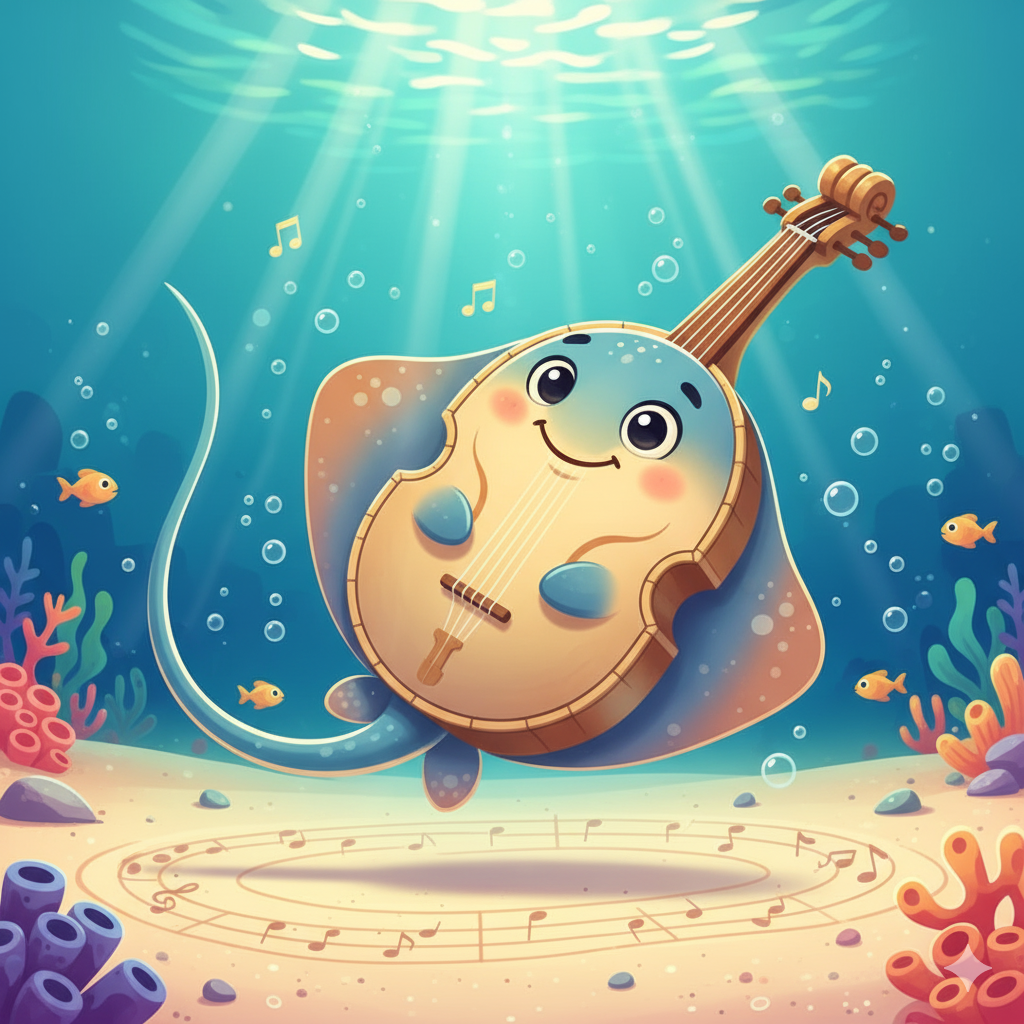

In [10]:

import os
from PIL import Image
from IPython.display import display # 在 Jupyter/Colab 环境中用于显示图片

# ----------------- 配置文件和路径 -----------------

# 本地图片文件夹名称路径
IMAGE_FOLDER = "fish_ic"

# 测试用的儿童名字
test_child_name = "Jason"

# ----------------- 1. 获取名字对应的身份 -----------------

# 调用 Step 3 中的主集成函数来获取所有身份信息
# 保证前面的函数定义（包括 get_full_identity_with_dynamic_image）已在内存中
try:
    final_result = get_full_identity_with_dynamic_image(test_child_name)
    print(f"身份生成成功 for: {test_child_name}")

    # 2. 提取英文物种名 (species_en)
    species_en = final_result["Complete_Base_Marine_Identity"]["Species_Name_EN"]
    print(f"   - 对应的物种 (species_en): {species_en}")

    # 3. 构造本地图片路径

    local_image_path = os.path.join(IMAGE_FOLDER, f"{species_en}.png")

    # 4. 尝试读取和显示图片
    print(f"   - 尝试加载图片路径: {local_image_path}")

    if not os.path.exists(local_image_path):
        print(f"❌ 错误：图片文件未找到！请检查以下事项：")
        print(f"   1. 是否有名为 '{IMAGE_FOLDER}' 的文件夹？")
        print(f"   2. 文件夹中是否有名为 '{species_en}.png' 的文件？")
        print(f"   3. 文件名是否包含空格和大小写错误？")
    else:
        # 打开并显示图片
        img = Image.open(local_image_path)
        print(f"✅ 图片加载成功！正在尝试显示...")

        # 显示图片（在支持 PIL/IPython 的环境中）
        display(img)

except NameError:
    print("❌ 错误：请确保所有之前的函数定义（特别是 get_full_identity_with_dynamic_image）都已运行。")
except Exception as e:
    print(f"❌ 发生了一个意外错误: {e}")


